##Homework 1, DSCI-D590: Applied Data Science; Owen Randolph, 9.15.2024


This dataset is called "Los Angeles International Airport Cargo Volume".  This notebook includes loading and checking the dataset, assessing data quality and missing values, and applying some basic analyses to explore and gain insights into what the data is showing.

URL: https://catalog.data.gov/dataset/los-angeles-international-airport-air-cargo-volume.  
The publisher of this data is the City of Los Angeles (data.lacity.org). No specific author is given.
The first publication date is 05-31-2014, last modified on 11-30-2023.

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
import pandas as pd

# Read CSV file from working directory
data = pd.read_csv("LAXCargo.csv")

# Display first 5 rows
data.head()

,DataExtractDate,ReportPeriod,Arrival_Departure,Domestic_International,CargoType,AirCargoTons
0,2014-05-01T00:00:00.000,2006-01-01T00:00:00.000,Arrival,Domestic,Freight,35703
1,2014-05-01T00:00:00.000,2006-01-01T00:00:00.000,Arrival,Domestic,Mail,3209
2,2014-05-01T00:00:00.000,2006-01-01T00:00:00.000,Arrival,International,Freight,46391
3,2014-05-01T00:00:00.000,2006-01-01T00:00:00.000,Arrival,International,Mail,548
4,2014-05-01T00:00:00.000,2006-01-01T00:00:00.000,Departure,Domestic,Freight,36702


The dependent variable values, AirCargoTons, are measured in tons of cargo that moved in and out through the airport on each day shown in the ReportPeriod Column.  Each row has one combination of Departure/Arrival, International/Domestic, and Freight/Mail for each day.

##Data Quality

In [11]:
# Check the number of rows and columns of dataset
data.shape

(1280, 6)

In [12]:
# Check Data Types in Columns
data.dtypes

,0
DataExtractDate,object
ReportPeriod,object
Arrival_Departure,object
Domestic_International,object
CargoType,object
AirCargoTons,int64


In [13]:
# Display summary statistics
data.describe()

,AirCargoTons
count,1280.000000
mean,21249.753906
std,21172.191210
min,454.000000
25%,1679.000000
50%,15392.500000
75%,37013.500000
max,82352.000000


In [14]:
# Check for Missing Values
data.isnull().sum()

,0
DataExtractDate,0
ReportPeriod,0
Arrival_Departure,0
Domestic_International,0
CargoType,0
AirCargoTons,0


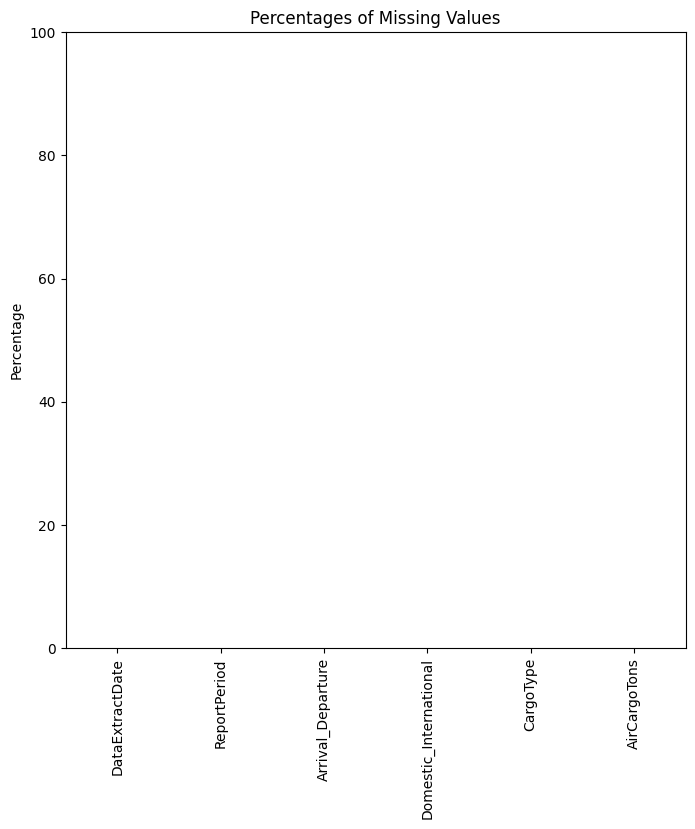

In [15]:
# Visual Assessment of Missing Values For Each Variable
(data.isnull().mean() * 100).plot(kind='bar', figsize=(8,8), title="Percentages of Missing Values")
plt.ylabel('Percentage')
plt.ylim(0, 100)
plt.show()

##Data Visualization

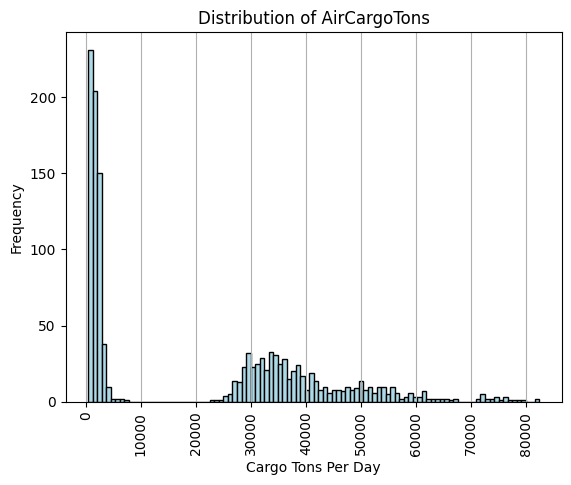

In [135]:
# Create a histogram of AirCargoTons
plt.hist(data['AirCargoTons'], bins=100, edgecolor='black', color = 'lightblue')

# Add labels
plt.title("Distribution of AirCargoTons")
plt.xlabel("Cargo Tons Per Day")
plt.ylabel("Frequency")

#Adjust ticks on x axis for uniformity
plt.xticks(ticks = range(0, 83000, 10000), rotation = 90)
plt.grid(axis='x')

# Show the plot
plt.show()

For this histogram showing the total distribution, because n > 150, 100 bins are used.  It is clear that we are looking at two subsets of data in this total. It shows a high concentration of load totals under 9,000 tons, and another more distributed group of load totals from about 22,000 to 83,000 tons per day.  This total dataset is skewed right (positive skew), as the meaning around 21,000.




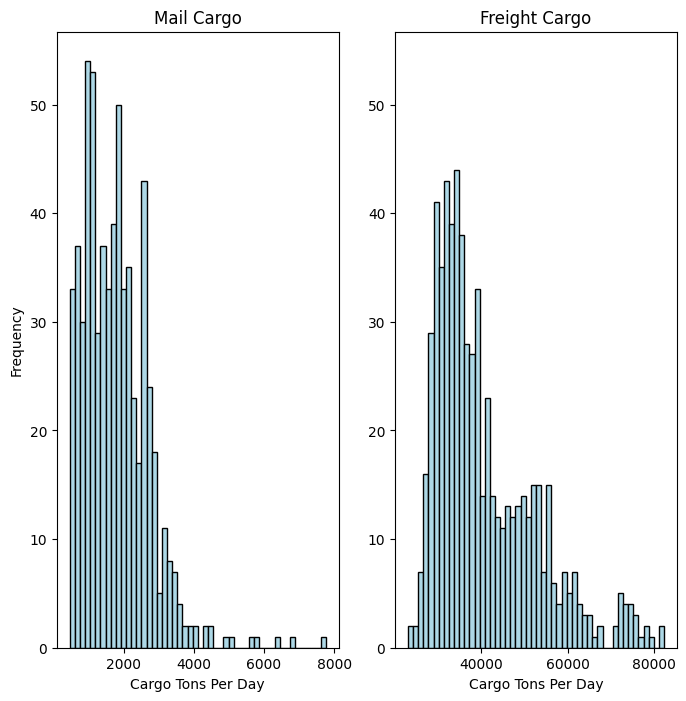

In [134]:
# Divide the total into two box plots by Cargo Type
mail_loads = data['CargoType'] == "Mail"
freight_loads = data['CargoType'] == "Freight"

fig, axs = plt.subplots(1, 2, figsize=(8, 8), sharey= True)

axs[0].hist(data[mail_loads]['AirCargoTons'], bins=50, edgecolor='black', color = "lightblue")
axs[0].set_title('Mail Cargo')
axs[0].set_xlabel('Cargo Tons Per Day')

axs[0].set_ylabel('Frequency')

axs[1].hist(data[freight_loads]['AirCargoTons'], bins=50, edgecolor='black', color = "lightblue")
axs[1].set_title('Freight Cargo')
axs[1].set_xlabel('Cargo Tons Per Day')
axs[1].tick_params(axis='y', which='both', labelleft= True)

plt.show()

When we break the total distribution down by cargo type, we can see the grouping more clearly.  These are both skewed positively to the right, as they both have tails that extend to include higher values.  As we can see, the varience for Freight Cargo is much greater (scale is larger in Freight histogram).  The subsequent visualizations will take this into consideration and provide insights for each of the two cargo type groups for more accurate data analysis.

<ipython-input-128-88cd962aaf09>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Domestic_International', y = 'AirCargoTons', data=mail_loads, ax=axs[0], palette = "colorblind")
<ipython-input-128-88cd962aaf09>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Domestic_International', y = 'AirCargoTons', data=freight_loads, ax=axs[1], palette = "colorblind")


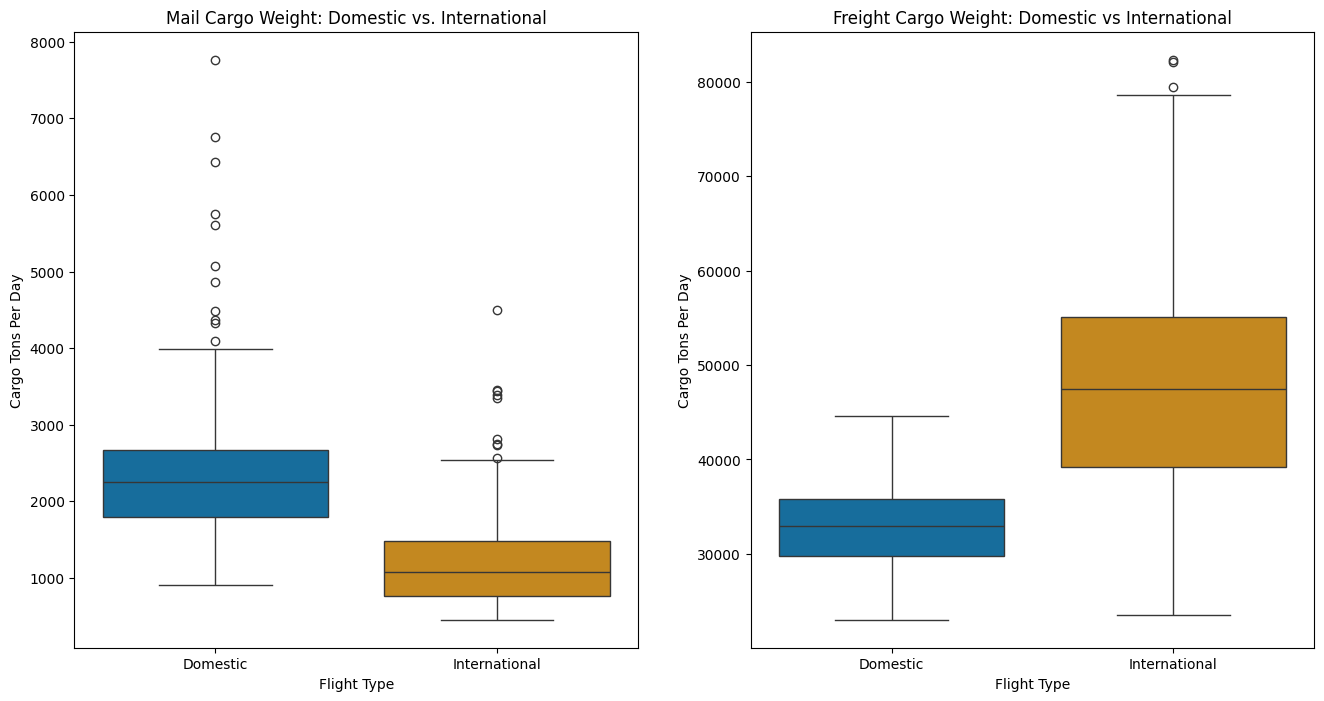

In [128]:
# Create box plots to compare domestic versus international cargo loads
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

# Filter to create two subsets including Domestic/International and volumes
mail_loads = data[data['CargoType'] == 'Mail'][['Domestic_International', 'AirCargoTons']]
freight_loads = data[data['CargoType'] == 'Freight'][['Domestic_International', 'AirCargoTons']]

# Mail Cargo box plots
sns.boxplot(x='Domestic_International', y = 'AirCargoTons', data=mail_loads, ax=axs[0], palette = "colorblind")
axs[0].set_title('Mail Cargo Weight: Domestic vs. International')
axs[0].set_xlabel('Flight Type')
axs[0].set_ylabel('Cargo Tons Per Day')

# Freight Cargo box plots
sns.boxplot(x='Domestic_International', y = 'AirCargoTons', data=freight_loads, ax=axs[1], palette = "colorblind")
axs[1].set_title('Freight Cargo Weight: Domestic vs International')
axs[1].set_xlabel('Flight Type')
axs[1].set_ylabel('Cargo Tons Per Day')

plt.show()

On average, about twice as much domestic mail goes through LAX than international mail.  Numerous outliers are shown in domestic mail, perhaps due to holidays having much heavier mailing activity.  However, for freight, international loads are generally higher than domestic loads, and they have significantly higher variance.

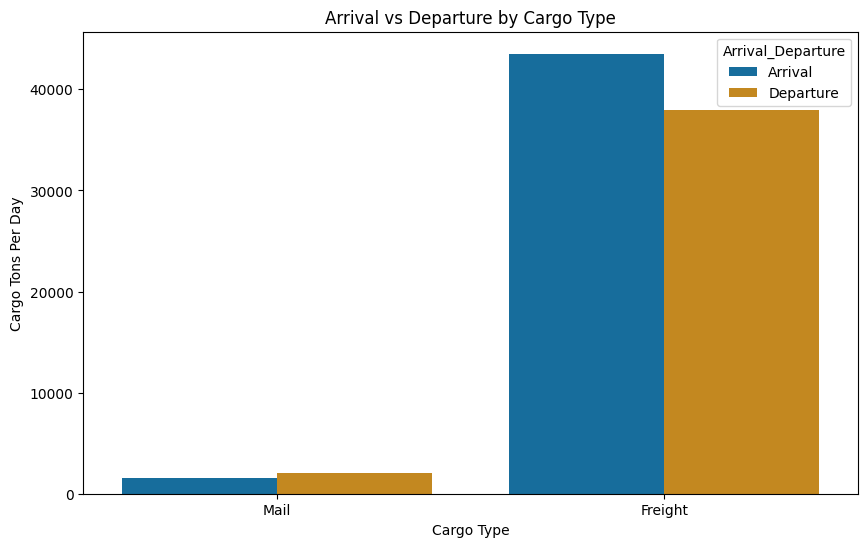

In [127]:
# Create bar charts to show Arrivals/Departures by weight
# Customize the pallet to reflect colors of previous groupings

plt.figure(figsize=(10, 6))
sns.barplot(x='CargoType', y='AirCargoTons', hue='Arrival_Departure', data=data, order=['Mail', 'Freight'], errorbar=None, hue_order=['Arrival', 'Departure'], palette="colorblind")
plt.title('Arrival vs Departure by Cargo Type')
plt.xlabel('Cargo Type')
plt.ylabel('Cargo Tons Per Day')
plt.show()

More freight is arriving into LAX than is departing, but marginally more mail is leaving the airport than is arriving into it.  As before, we can see the vast difference in volumes of freight loads and mail loads going through LAX.

**Resources:**

McKinney, W. (2022). Python for Data Analysis: Data Wrangling with Pandas, NumPy, and Jupyter (3rd ed.). O'Reilly Media.

OpenAI. (2024). ChatGPT 4o (Sept 2024 version) [Large language model]. https://chat.openai.com/chat

DataCamp. (n.d.). Introduction to Matplotlib. DataCamp. https://www.datacamp.com/courses/introduction-to-matplotlib